<a href="https://colab.research.google.com/github/ssleona67/Integracion-de-datos-y-prospectiva/blob/main/3_Integraci%C3%B3n_Datos_Cosco.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Caso Estudio - Primer Método Integración**

El primer método de integración se conoce como el método de muestreo (muestreo por clusterización - Montecarlo). Este método esta determinado por el índice de confiabilidad. De manera general la confiabilidad a norma internacional esta marcado por una confiabilidad del 99.9%, lo que requerira como minimo tener un total de 1000 datos.

0. Cargamos las librerias de trabajo

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns  #Las gráficas estadísticas
import matplotlib.pyplot as plt

1. Cargamos los datos de trabajo

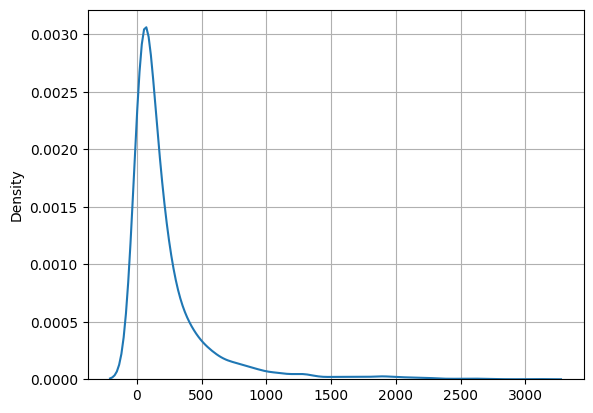

In [2]:
nxl='/content/1. RiesgoOperacional_EVERGREEEN.xlsx'
XDB=pd.read_excel(nxl,sheet_name=0)
#display(XDB)
Freq=XDB.iloc[:,3]; Sev=XDB.iloc[:,4]
LDA=Freq*Sev

plt.figure()
sns.kdeplot(LDA)
plt.grid()
plt.show()

2. Se procede con la creación de los concentradores de información

In [3]:
import random
random.seed(42)
XC=np.array(random.choices(LDA,k=5))
XC=np.sort(XC)
print("Los concentradores de información son:",XC)

Los concentradores de información son: [ 66.68668397  83.48720974  85.08350368 192.09214682 203.24462183]


3. Se clasifican los datos de acuerdo con los concentradores de información

In [14]:
box0=[];box1=[];box2=[];box3=[];box4=[]
Boxes=[box0,box1,box2,box3,box4]

for k in range(len(LDA)):
  d=np.abs(XC-LDA.iloc[k,])/XC #la distancia de un dato a un concentrador
  nc=np.argmin(d)  #Número de la caja en donde voy a introducir el dato
  #print("Las distancia porcentuales son:",d)
  #print("El dato pertenece a la categorías:",nc)
  XC[nc,]=(XC[nc,]+LDA.iloc[k,])/2
  Boxes[nc].append(LDA.iloc[k,])

#Determinamos el porcentaje de datos por Caja
pm=[]  #Vector de porcentajes
for j in range(5):
  pd=len(Boxes[j])/len(LDA)
  pm.append(pd)

pm=(np.array(pm)*1000).astype(int)
print("El porcentaje de los datos es:",pm)

El porcentaje de los datos es: [ 29  58 136 279 495]


4. Sacamos daticos por caja y creamos una LDA2

la media de los datos observados es: 231.2666023410175
la media de los datos externos es: 229.8465241904529
El error relativo porcentual es: 0.614043764291826


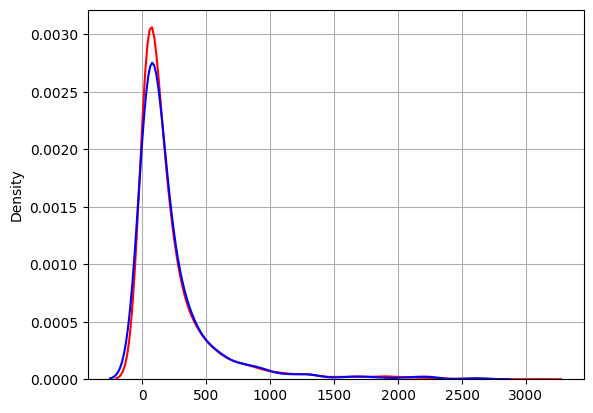

In [15]:
LDA2=[]  #Aquí van a quedar los 1000 datos

for j in range(5):
  LDA2.extend(random.choices(Boxes[j],k=pm[j]))

LDA2=np.array(LDA2)

#Se comprueban las métricas estadísticas
uo=np.mean(LDA)
print("la media de los datos observados es:",uo)
ue=np.mean(LDA2)
print("la media de los datos externos es:",ue)
du=np.abs((uo-ue)/uo)
print("El error relativo porcentual es:",du*100)

plt.figure()
sns.kdeplot(LDA,color='red',label='Datos Observados')
sns.kdeplot(LDA2,color='blue',label='Datos Externos')
plt.grid()
plt.show()
#

**Análisis de Resultados**
De acuerdo con el método de integración de datos por muestreo aleatorio y concentradores de información, la discrepancia que se obtuvo para la media de las distribuciones (Datos Observados:LDA, Datos Externos:LDA2) estuvo por debajo del 5% en promedio, lo que indica que el 95% de los datos aproximadamente fueron correctamente seleccionados. Este proceso de muestreo se hizo con el fin de lograr una confiabilidad del 99,9% en la estimación de las pérdidas por dejar contenedores en tierra. Es importante mencionar que las medias de los datos observadoes y los externos fueron bla, bla, bla, las desviaciones fueron bla, bla, bla, los coeficientes asimetría fueron tales y tales, y la curtosis fueron tales y tales (es que fueron muy similares).

Integracion datos COSCO (datos externos)

En esta parte la naviera evergreen quier eintegrar los dato logisticos de la operacion de COSCO shipping. Para lo cual utilizara el modelo k-medoids

1. Se carga la base de datos de COSCO shipping

,Mensual,Transacción Mensuales (Mes),Valor Transado (MUSD),Eventos (Mes),Severidad (KUSD)
0,1,16,16.840771,1,0.971171
1,2,66,31.694407,8,2.267038
2,3,127,16.901201,10,0.975352
3,4,113,25.340976,11,4.453477
4,5,192,24.096199,16,2.937216
...,...,...,...,...,...
495,496,22,11.492619,2,1.471331
496,497,91,41.608338,3,2.618779
497,498,29,54.306981,3,5.996600
498,499,126,143.389211,19,15.343642


La media de los externos es: 60.70724412540753
el coeficiente de asimetría es: 3.1642367700246283
la curtosis es: 12.024762972960977


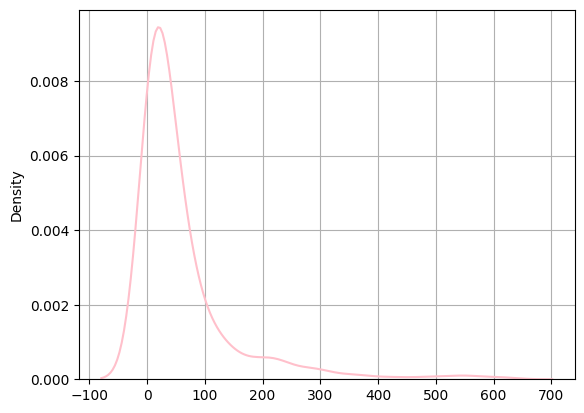

In [10]:
import pandas as pd
nxle= '/content/3. Datos COSCO Shipping.xlsx'
XDBe=pd.read_excel(nxle,sheet_name=0)
display(XDBe)

Freqe=XDBe.iloc[:,3]
Seve=XDBe.iloc[:,4]
LDAe= Freqe*Seve
print("La media de los externos es:", np.mean(LDAe))
print("el coeficiente de asimetría es:", LDAe.skew())
print("la curtosis es:", LDAe.kurtosis())

plt.figure()
sns.kdeplot(LDAe, color='pink')
plt.grid()
plt.show()
#

2. Se procede con la integracion de los datos externos

In [27]:
LDAe=np.array(LDAe)
m1=0 #cuantos datos he integrado

for k in range(len(LDAe)):
  VP=np.exp(-0.5*((XC-LDAe[k,])/XC)**2) #a cual caja pertenece el dato
  #print("los valores de pertenencia a los clusters internos son:", VP)

  if np.max(VP)>0.90:
    m1=m1+1
    #print("se integra el rato")
    nc=np.argmax(VP)
    Boxes[nc].append(LDAe[k,])
    XC[nc,]=(XC[nc,]+LDAe[k,])/2

print("los datos integrados fueron:", m1)



los datos integrados fueron: 258


3. Procedemos a hacer un muestreo de las cajas

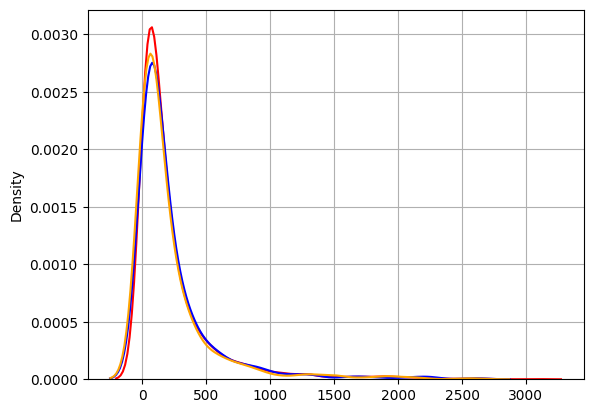

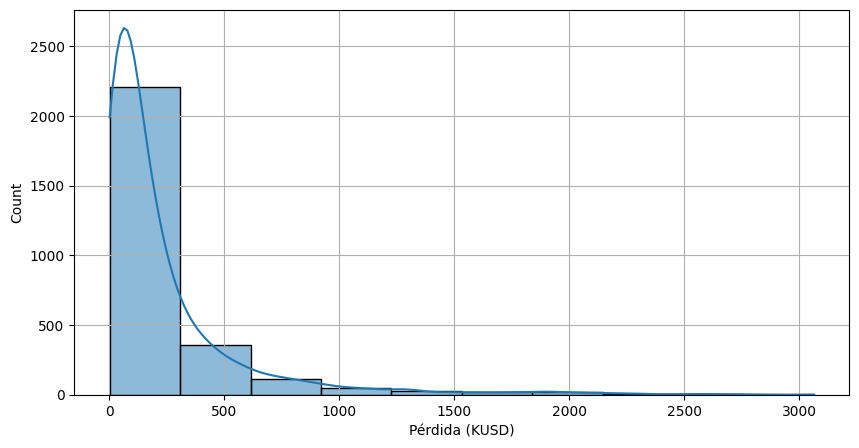

El número de datos por intervalo es:
[2209  356  116   46   27   18   20    7    4    1]
Los intervalos inferiores:
[   2.59919687  308.92945016  615.25970344  921.58995673 1227.92021002
 1534.25046331 1840.5807166  2146.91096988 2453.24122317 2759.57147646]
Los intervalos superiores:
[ 308.92945016  615.25970344  921.58995673 1227.92021002 1534.25046331
 1840.5807166  2146.91096988 2453.24122317 2759.57147646 3065.90172975]
la media de la distribucion original es: 279.6510949925361
el coeficiente de asimetria para la distribucion original es: 3.792311305904773


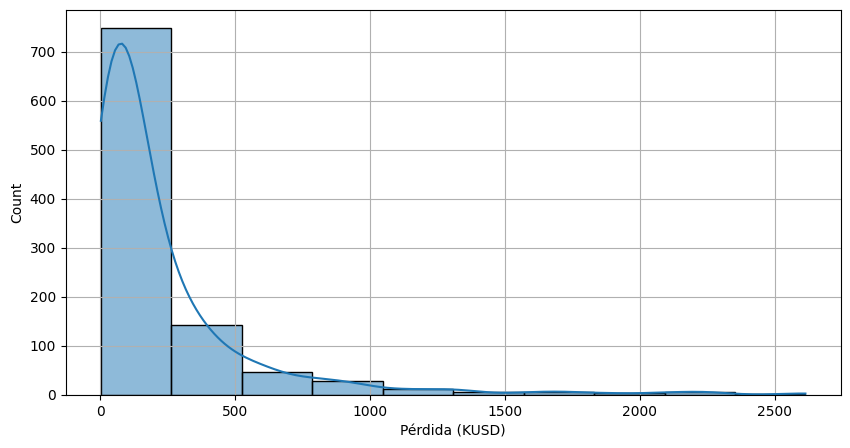

El número de datos por intervalo es:
[748 142  46  27  12   6   5   3   6   2]
Los intervalos inferiores:
[   2.68468013  263.8758335   525.06698688  786.25814026 1047.44929363
 1308.64044701 1569.83160038 1831.02275376 2092.21390714 2353.40506051]
Los intervalos superiores:
[ 263.8758335   525.06698688  786.25814026 1047.44929363 1308.64044701
 1569.83160038 1831.02275376 2092.21390714 2353.40506051 2614.59621389]
la media de la distribucion muestreada es: 266.88856997635946
el coeficiente de asimetria para la distribucion muestreada es: 3.67855989493065


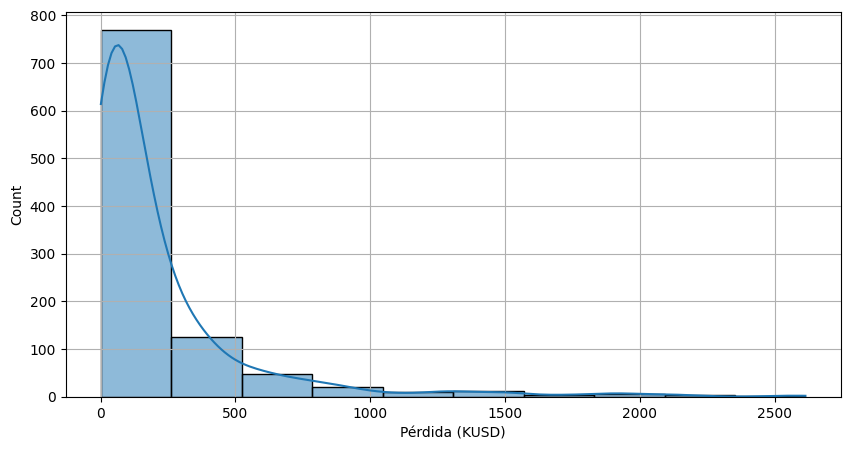

El número de datos por intervalo es:
[769 125  47  21   9  11   4   6   3   2]
Los intervalos inferiores:
[   0.96562881  262.32868732  523.69174582  785.05480433 1046.41786284
 1307.78092135 1569.14397986 1830.50703836 2091.87009687 2353.23315538]
Los intervalos superiores:
[ 262.32868732  523.69174582  785.05480433 1046.41786284 1307.78092135
 1569.14397986 1830.50703836 2091.87009687 2353.23315538 2614.59621389]
la media de la distribucion integrada datos externos es: 257.741070942082
el coeficiente de asimetria para la distribucion integrada datos externos es: 3.700764893391775


In [50]:
import scipy.stats
import pandas as pd # Re-import pandas to ensure 'pd' refers to the pandas module

LDA2e=[]  #Aquí van a quedar los 1000 datos

for j in range(5):
  LDA2e.extend(random.choices(Boxes[j],k=pm[j]))

LDA2e=np.array(LDA2e)

plt.figure()
sns.kdeplot(LDA, color='red')
sns.kdeplot(LDA2, color='blue')
sns.kdeplot(LDA2e, color='orange')
plt.grid()
plt.show()

#se muestran las metricas para cada distribucion
p1,p2,p3,p4,p5=caracterizacion(LDA)
print("la media de la distribucion original es:", p1)
print("el coeficiente de asimetria para la distribucion original es:", p3)

p1,p2,p3,p4,p5=caracterizacion(LDA2)
print("la media de la distribucion muestreada es:", p1)
print("el coeficiente de asimetria para la distribucion muestreada es:", p3)

p1,p2,p3,p4,p5=caracterizacion(LDA2e)
print("la media de la distribucion integrada datos externos es:", p1)
print("el coeficiente de asimetria para la distribucion integrada datos externos es:", p3)

4. se integra el metodo de caracterizacion de variables aleatorias

In [47]:
def caracterizacion(LDA):

  #Se procede con la creación de la distribución
  plt.figure(figsize=(10,5))
  sns.histplot(LDA,bins=10,kde=True)
  plt.xlabel("Pérdida (KUSD)")
  plt.grid()
  plt.show()

  #Se procede con la caracterización de cada una de las variables
  np.set_printoptions(suppress=True)
  NI=10    #Indica el número de clusters
  counts,bin_edges=np.histogram(LDA,bins=NI)
  print("El número de datos por intervalo es:")
  print(counts)
  print("Los intervalos inferiores:")
  print(bin_edges[:-1])
  print("Los intervalos superiores:")
  print(bin_edges[1:])
  XC=(bin_edges[:-1]+bin_edges[1:])/2

  #Se configura la tabla de los datos
  Tabla=np.column_stack((bin_edges[:-1],bin_edges[1:],XC,counts))
  df=pd.DataFrame(Tabla,columns=['LI','LS','XC','ND'])
  df.head(10)

  #Se procede con la estimación de la media
  fr=counts/np.sum(counts)
  u=np.sum(XC*fr)
  sigma2=np.sum(fr*(XC-u)**2)
  sigma=np.sqrt(sigma2)
  Cas=np.sum(fr*(XC-u)**3)/sigma**3
  Kur=(np.sum(fr*(XC-u)**4)/sigma**4)-3

  return u,sigma,Cas,Kur,df